# Understanding Overfitting: The Costume Fitting Metaphor 👔

Imagine you're getting a costume made. The tailor takes measurements (training data) to create something that fits you perfectly:

- **Too Loose (Underfitting)**: Like a one-size-fits-all robe - it technically works but doesn't capture your shape
- **Just Right (Good Fit)**: A tailored costume that follows your contours with room to move and breathe
- **Too Tight (Overfitting)**: Follows every wrinkle and temporary bulge - perfect for one pose, but restrictive when you move

In machine learning, we face the same challenge: create a model that captures patterns without memorizing noise.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider, fixed
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

## 1. Generate Data: Taking Measurements

We'll generate synthetic data representing "body measurements" with some natural variation (noise).

In [9]:
def generate_data(n_train=30, n_test=100, noise_level=0.3, seed=42):
    """
    Generate training and test data.
    
    Think of this as:
    - Training data: Measurements taken at the tailor
    - Test data: How you'll actually look when wearing the costume later
    - Noise: Natural body variations, measurement errors
    """
    np.random.seed(seed)
    
    # Training data - limited measurements
    X_train = np.sort(np.random.uniform(0, 10, n_train))
    
    # True underlying function (the "true body shape")
    def true_function(x):
        return np.sin(x) + 0.1 * x
    
    y_train_true = true_function(X_train)
    y_train = y_train_true + noise_level * np.random.randn(n_train)
    
    # Test data - more points to see how well the model generalizes
    X_test = np.linspace(0, 10, n_test)
    y_test_true = true_function(X_test)
    y_test = y_test_true + noise_level * np.random.randn(n_test)
    
    return X_train, y_train, X_test, y_test, y_test_true

## 2. Fit the Costume: Polynomial Regression

The polynomial degree represents how "tailored" your costume is:
- **Degree 1**: Straight line - like a loose robe
- **Degree 3-5**: Moderate complexity - tailored fit
- **Degree 10+**: Extreme complexity - too tight, follows every measurement error

In [10]:
def fit_polynomial(X_train, y_train, X_test, y_test, degree):
    """
    Fit a polynomial model of given degree.
    
    Returns the model, predictions, and error metrics.
    """
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train.reshape(-1, 1))
    X_test_poly = poly.transform(X_test.reshape(-1, 1))
    
    # Fit linear regression on polynomial features
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    # Calculate errors
    train_error = mean_squared_error(y_train, y_train_pred)
    test_error = mean_squared_error(y_test, y_test_pred)
    
    return y_train_pred, y_test_pred, train_error, test_error

## 3. Calculate Error Curves

Let's see how training and test errors change with model complexity.

In [11]:
def calculate_error_curves(X_train, y_train, X_test, y_test, max_degree=15):
    """
    Calculate training and test errors for all polynomial degrees.
    """
    degrees = range(1, max_degree + 1)
    train_errors = []
    test_errors = []
    
    for degree in degrees:
        _, _, train_err, test_err = fit_polynomial(X_train, y_train, X_test, y_test, degree)
        train_errors.append(train_err)
        test_errors.append(test_err)
    
    return list(degrees), train_errors, test_errors

## 4. Interactive Visualization 🎮

Now for the fun part! Use the sliders to adjust:
- **Costume Tailoring** (Polynomial Degree): How complex is the fit?
- **Measurements** (Training Points): How many measurements did the tailor take?
- **Body Variation** (Noise Level): How much natural variation is there?

In [12]:
def plot_overfitting_demo(degree, n_train, noise_level):
    """
    Interactive visualization of the overfitting phenomenon.
    """
    # Generate data
    X_train, y_train, X_test, y_test, y_true = generate_data(n_train, 100, noise_level)
    
    # Fit model with current degree
    y_train_pred, y_test_pred, train_error, test_error = fit_polynomial(
        X_train, y_train, X_test, y_test, degree
    )
    
    # Calculate error curves for all degrees
    degrees, train_errors, test_errors = calculate_error_curves(
        X_train, y_train, X_test, y_test, max_degree=15
    )
    
    # Determine fit quality
    if degree <= 2:
        fit_status = "UNDERFITTING (Too Loose)"
        fit_color = "#3498db"  # Blue
        explanation = "Like a baggy robe - doesn't capture the shape!"
    elif degree <= 5:
        fit_status = "GOOD FIT (Just Right)"
        fit_color = "#2ecc71"  # Green
        explanation = "Tailored perfectly - follows the pattern with room to move!"
    else:
        fit_status = "OVERFITTING (Too Tight)"
        fit_color = "#e74c3c"  # Red
        explanation = "Too specific - follows every measurement error!"
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # TOP PLOT: Data and fitted curve
    ax1.scatter(X_train, y_train, color='navy', s=100, alpha=0.6, 
                label=f'Training Data ({n_train} measurements)', zorder=3, edgecolors='black', linewidth=1.5)
    ax1.plot(X_test, y_true, 'g--', linewidth=2, alpha=0.5, label='True Pattern', zorder=1)
    ax1.plot(X_test, y_test_pred, color=fit_color, linewidth=3, 
             label=f'Fitted Costume (Degree {degree})', zorder=2)
    
    ax1.set_xlabel('Position', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Measurement', fontsize=12, fontweight='bold')
    ax1.set_title(f'🎭 {fit_status}\n{explanation}', 
                  fontsize=14, fontweight='bold', color=fit_color, pad=20)
    ax1.legend(loc='upper left', fontsize=11, framealpha=0.9)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(y_train.min() - 0.5, y_train.max() + 0.5)
    
    # Add error information
    error_text = f'Training Error: {train_error:.4f}\nTest Error: {test_error:.4f}\nGap: {abs(test_error - train_error):.4f}'
    ax1.text(0.98, 0.02, error_text, transform=ax1.transAxes, 
             fontsize=10, verticalalignment='bottom', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # BOTTOM PLOT: Error curves
    ax2.plot(degrees, train_errors, 'o-', color='#3498db', linewidth=2, 
             markersize=6, label='Training Error', alpha=0.8)
    ax2.plot(degrees, test_errors, 's-', color='#e74c3c', linewidth=2, 
             markersize=6, label='Test Error', alpha=0.8)
    
    # Highlight current degree
    ax2.axvline(degree, color=fit_color, linestyle='--', linewidth=3, alpha=0.7, 
                label=f'Current Degree ({degree})')
    ax2.scatter([degree], [train_errors[degree-1]], color='#3498db', s=200, 
                zorder=5, edgecolors='black', linewidth=2)
    ax2.scatter([degree], [test_errors[degree-1]], color='#e74c3c', s=200, 
                zorder=5, edgecolors='black', linewidth=2)
    
    ax2.set_xlabel('Polynomial Degree (Costume Complexity)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Mean Squared Error', fontsize=12, fontweight='bold')
    ax2.set_title('📊 Training vs Test Error: Finding the Sweet Spot', 
                  fontsize=14, fontweight='bold', pad=15)
    ax2.legend(loc='upper right', fontsize=11, framealpha=0.9)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0.5, 15.5)
    
    # Add zones
    ax2.axvspan(0.5, 2.5, alpha=0.1, color='#3498db', label='Underfit Zone')
    ax2.axvspan(2.5, 5.5, alpha=0.1, color='#2ecc71', label='Sweet Spot')
    ax2.axvspan(5.5, 15.5, alpha=0.1, color='#e74c3c', label='Overfit Zone')
    
    plt.tight_layout()
    plt.show()
    
    # Print interpretation
    print("\n" + "="*60)
    print(f"📏 COSTUME FITTING REPORT - Degree {degree}")
    print("="*60)
    print(f"Status: {fit_status}")
    print(f"Training Error: {train_error:.4f} (How well it fits your measurements)")
    print(f"Test Error: {test_error:.4f} (How well it fits when you move)")
    print(f"Error Gap: {abs(test_error - train_error):.4f} (Bigger gap = more overfitting)")
    print("\n💡 Key Insight:")
    if degree <= 2:
        print("   The costume is too simple! It doesn't capture your shape well.")
        print("   Try increasing the complexity (degree) to get a better fit.")
    elif degree <= 5:
        print("   Perfect! The costume fits well and will still work when you move.")
        print("   Notice how train and test errors are both low and similar.")
    else:
        print("   The costume is TOO tailored! It fits your measurements perfectly...")
        print("   But it's memorized noise and won't generalize to new poses.")
        print("   Notice the large gap between training and test error!")
    print("="*60)

In [13]:
# Create the interactive widget
interact(
    plot_overfitting_demo,
    degree=IntSlider(min=1, max=15, step=1, value=3, description='🎯 Tailoring:', style={'description_width': 'initial'}),
    n_train=IntSlider(min=10, max=80, step=5, value=30, description='📏 Measurements:', style={'description_width': 'initial'}),
    noise_level=FloatSlider(min=0.0, max=1.0, step=0.1, value=0.3, description='📊 Variation:', style={'description_width': 'initial'})
);

interactive(children=(IntSlider(value=3, description='🎯 Tailoring:', max=15, min=1, style=SliderStyle(descript…

## 🎓 Key Takeaways

### The Costume Fitting Analogy

1. **Underfitting (Too Loose)**
   - Model is too simple (low polynomial degree)
   - Doesn't capture the underlying pattern
   - High training error AND high test error
   - Like a one-size-fits-all robe

2. **Good Fit (Just Right)**
   - Model complexity matches problem complexity
   - Captures the pattern without memorizing noise
   - Low training error AND low test error (similar values)
   - Like a well-tailored costume with room to move

3. **Overfitting (Too Tight)**
   - Model is too complex (high polynomial degree)
   - Memorizes training data including noise
   - Very low training error BUT high test error
   - Like a costume sewn to one specific pose

### What to Watch For

- **Error Gap**: The difference between training and test error is the key indicator
  - Small gap = good generalization
  - Large gap = overfitting

- **Training Points**: More data helps, but won't fix a fundamentally wrong model complexity

- **Noise Level**: More noise makes overfitting easier (more "wrinkles" to memorize)

### Try These Experiments

1. Set degree=1, then gradually increase. Watch how test error first decreases, then increases!
2. Use very few training points (10-15) with high degree (12+). See extreme overfitting!
3. Compare degree=3 vs degree=10 with noise=0. Even without noise, high complexity can overfit!
4. Increase training points to 60+ and see how it helps prevent overfitting at higher degrees

## 🔬 Extra: Visualize Multiple Fits at Once

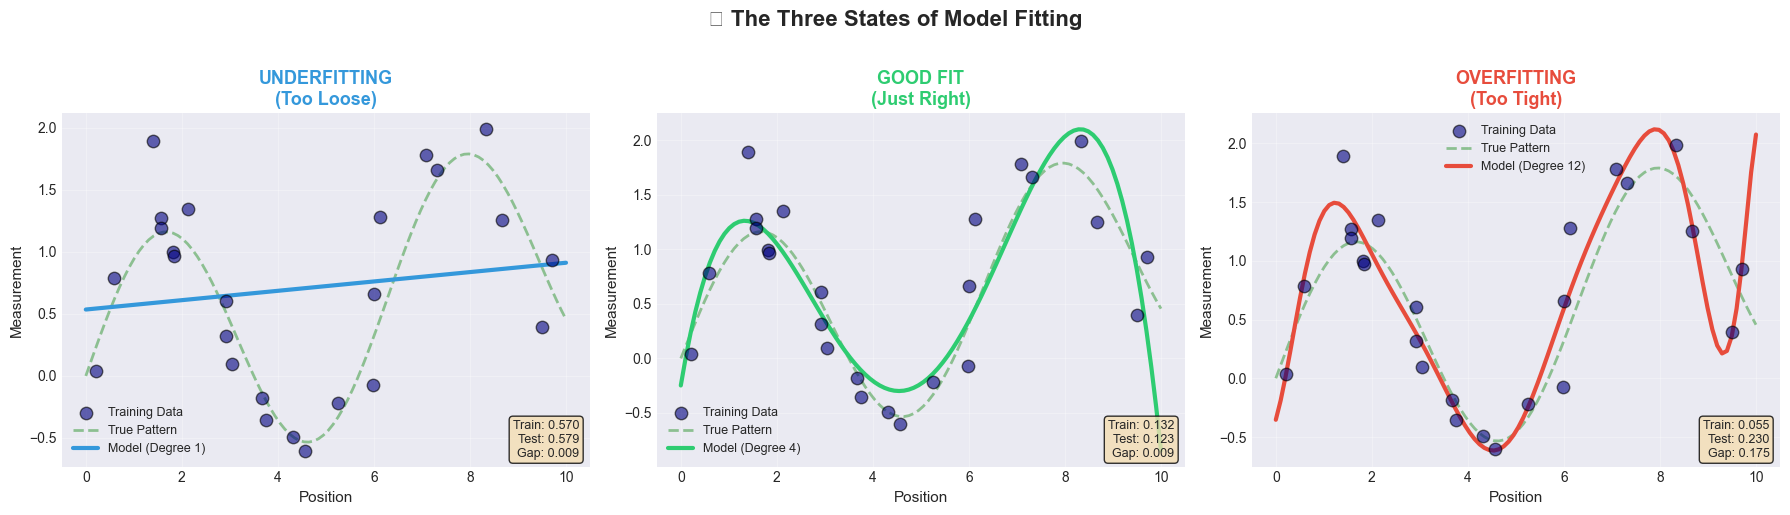

In [14]:
def compare_multiple_degrees():
    """
    Show underfit, good fit, and overfit side by side.
    """
    X_train, y_train, X_test, y_test, y_true = generate_data(n_train=25, noise_level=0.3)
    
    degrees_to_compare = [1, 4, 12]
    titles = ['UNDERFITTING\n(Too Loose)', 'GOOD FIT\n(Just Right)', 'OVERFITTING\n(Too Tight)']
    colors = ['#3498db', '#2ecc71', '#e74c3c']
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for ax, degree, title, color in zip(axes, degrees_to_compare, titles, colors):
        y_train_pred, y_test_pred, train_err, test_err = fit_polynomial(
            X_train, y_train, X_test, y_test, degree
        )
        
        ax.scatter(X_train, y_train, color='navy', s=80, alpha=0.6, 
                   label='Training Data', zorder=3, edgecolors='black')
        ax.plot(X_test, y_true, 'g--', linewidth=2, alpha=0.4, label='True Pattern', zorder=1)
        ax.plot(X_test, y_test_pred, color=color, linewidth=3, 
                label=f'Model (Degree {degree})', zorder=2)
        
        ax.set_title(title, fontsize=13, fontweight='bold', color=color)
        ax.set_xlabel('Position', fontsize=11)
        ax.set_ylabel('Measurement', fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        
        # Add error info
        error_text = f'Train: {train_err:.3f}\nTest: {test_err:.3f}\nGap: {abs(test_err-train_err):.3f}'
        ax.text(0.98, 0.02, error_text, transform=ax.transAxes, 
                fontsize=9, verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.suptitle('🎭 The Three States of Model Fitting', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

compare_multiple_degrees()

## 🎯 Challenge Questions

Test your understanding:

1. **What polynomial degree gives the best balance?** (Hint: Around 3-5)

2. **What happens if you have only 10 training points and use degree 12?**

3. **Can you overfit with degree 2?** Try setting noise to 0 and see!

4. **How does increasing training points help prevent overfitting?**

5. **Real-world analogy**: If you're building a spam filter, what would represent:
   - Training data?
   - Overfitting?
   - The cost of overfitting?